# Evaluering av hierarkisk CNN

Kun evaluering, valg av beste epoch, tabeller og figurer.

In [1]:

from pathlib import Path
import gc, re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

tf.config.optimizer.set_jit(False)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except Exception:
        pass


2026-03-15 13:38:54.117498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 13:38:54.144864: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 13:38:54.732586: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

SEED = 42
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
EVAL_SPLIT = "val"                   # "val" eller "test"
RUN_TAG = "baseline_architecture"    # må matche treningsskriptet

tf.random.set_seed(SEED)
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "datasplitt_preprocessed").exists():
            return p
    raise FileNotFoundError("Fant ikke prosjektrot")

PROJECT_ROOT = find_project_root(Path.cwd())
TRAIN_CSV = PROJECT_ROOT / "datasplitt_preprocessed" / "train_processed.csv"
VAL_CSV   = PROJECT_ROOT / "datasplitt_preprocessed" / "val_processed.csv"
TEST_CSV  = PROJECT_ROOT / "datasplitt_preprocessed" / "test_processed.csv"
IMG_ROOT  = PROJECT_ROOT / "datasett_preprocessed"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

PATH_COL = "processed_image" if "processed_image" in train_df.columns else "image"
for df in (train_df, val_df, test_df):
    if "w_lvl1" not in df.columns:
        df["w_lvl1"] = 1.0

num_lvl2 = int(train_df.loc[train_df["w_lvl2"] > 0, "y_lvl2"].max()) + 1
lvl2_classes = (
    train_df.loc[train_df["w_lvl2"] > 0, ["lvl2", "y_lvl2"]]
    .drop_duplicates()
    .sort_values("y_lvl2")["lvl2"]
    .astype(str)
    .tolist()
)

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_TAG:", RUN_TAG)
print("EVAL_SPLIT:", EVAL_SPLIT, "| n =", len(eval_df))


PROJECT_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions
RUN_TAG: baseline_architecture
EVAL_SPLIT: val | n = 807


In [3]:

def decode_ready_image(path: tf.Tensor) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.ensure_shape(img, [IMG_SIZE[0], IMG_SIZE[1], 3])
    return img

def build_model():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(256, activation="relu")(x)
  

    out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
    out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

    model = keras.Model(inputs=inputs, outputs={"lvl1": out_lvl1, "lvl2": out_lvl2}, name="Modell_256_Dense.v2")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=6e-4),
        loss={"lvl1": keras.losses.BinaryCrossentropy(), "lvl2": keras.losses.SparseCategoricalCrossentropy()},
        metrics={"lvl1": [keras.metrics.BinaryAccuracy(name="acc")]},
        weighted_metrics={"lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")]},
        jit_compile=False,
    )
    return model

def predict_heads(model, df, batch_size=16):
    paths = [str(IMG_ROOT / p) for p in df[PATH_COL].astype(str).to_list()]
    lvl1_parts, lvl2_parts = [], []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        x = tf.stack([decode_ready_image(tf.constant(path)) for path in batch_paths], axis=0)
        preds = model(x, training=False)
        lvl1_parts.append(preds["lvl1"].numpy().reshape(-1))
        lvl2_parts.append(preds["lvl2"].numpy())
    return np.concatenate(lvl1_parts, axis=0), np.concatenate(lvl2_parts, axis=0)


In [4]:

def plot_cm_2x2(cm, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.0))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

def _lvl1_metrics_row(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    tnr = tn / (tn + fp) if (tn + fp) else np.nan
    row = {
        "lighting": name,
        "n_total": int(len(y_true)),
        "n_other": int((y_true == 0).sum()),
        "n_tesla": int((y_true == 1).sum()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "TPR": tpr, "TNR": tnr,
        "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
        "lvl1_acc": accuracy_score(y_true, y_pred),
        "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(y_true),
    }
    return row, cm

def eval_lvl1_by_lighting(model, df, threshold=0.5, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), batch_size=16):
    rows, cms = [], {}
    p1_all, _ = predict_heads(model, df, batch_size=batch_size)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)
    total_row, total_cm = _lvl1_metrics_row("Total", y_true_all, y_pred_all)
    rows.append(total_row); cms["Total"] = total_cm
    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue
        row, cm = _lvl1_metrics_row(light, y_true_all[mask], y_pred_all[mask])
        rows.append(row); cms[light] = cm
    return pd.DataFrame(rows), cms

def _lvl2_metrics_row(name, y_true, y_pred):
    counts = np.bincount(y_true, minlength=num_lvl2)
    maj_acc = counts.max() / len(y_true) if len(y_true) else np.nan
    row = {
        "lighting": name,
        "n_tesla": int(len(y_true)),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": maj_acc,
    }
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
    return row, cm, cm_norm

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), batch_size=16):
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    _, p2 = predict_heads(model, tesla_df, batch_size=batch_size)
    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    total_row, cm, cm_norm = _lvl2_metrics_row("Total", y_true, y_pred)
    rows, cm_norm_by_light = [total_row], {"Total": cm_norm}
    for light in lighting_order:
        mask = (tesla_df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue
        row, _, cm_l_norm = _lvl2_metrics_row(light, y_true[mask], y_pred[mask])
        rows.append(row)
        cm_norm_by_light[light] = cm_l_norm

    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0)
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm.sum(axis=1)[i])))
    df_confusions = pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"]).sort_values(["rate", "support_true"], ascending=[False, False]).head(5)

    return pd.DataFrame(rows), df_per_class, df_confusions, cm_norm_by_light


## Velg beste epoch og last modellen

In [5]:

ckpt_dir = PROJECT_ROOT / "checkpoints" / RUN_TAG
ckpt_files = sorted(ckpt_dir.glob("epoch_*.weights.h5"))

rows = []
for ckpt in ckpt_files:
    tf.keras.backend.clear_session()
    gc.collect()
    tmp_model = build_model()
    tmp_model.load_weights(str(ckpt))

    df_lvl1_tmp, _ = eval_lvl1_by_lighting(tmp_model, eval_df, threshold=0.5, batch_size=BATCH_SIZE)
    lvl1_total_f1 = float(df_lvl1_tmp.loc[df_lvl1_tmp["lighting"] == "Total", "lvl1_f1_macro"].iloc[0])

    df_lvl2_tmp, _, _, _ = eval_lvl2(tmp_model, eval_df, batch_size=BATCH_SIZE)
    lvl2_total_f1 = float(df_lvl2_tmp.loc[df_lvl2_tmp["lighting"] == "Total", "lvl2_f1_macro"].iloc[0])

    epoch_num = int(re.search(r"epoch_(\d+)", ckpt.name).group(1))
    rows.append({
        "epoch": epoch_num,
        "lvl1_total_f1_macro": lvl1_total_f1,
        "lvl2_total_f1_macro": lvl2_total_f1,
        "score_50_50": 0.5 * lvl1_total_f1 + 0.5 * lvl2_total_f1,
        "checkpoint": str(ckpt),
    })
    del tmp_model
    gc.collect()

epoch_scores = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(epoch_scores)

best_row = epoch_scores.sort_values("score_50_50", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])
best_ckpt = best_row["checkpoint"]

tf.keras.backend.clear_session()
gc.collect()
model = build_model()
model.load_weights(best_ckpt)

print("Best epoch:", best_epoch)
print("Best checkpoint:", best_ckpt)
print("Lvl1 Total F1:", round(float(best_row["lvl1_total_f1_macro"]), 4))
print("Lvl2 Total F1:", round(float(best_row["lvl2_total_f1_macro"]), 4))
print("50/50 score:", round(float(best_row["score_50_50"]), 4))


I0000 00:00:1773578351.872756   19301 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21546 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-03-15 13:39:12.298582: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variabl

,epoch,lvl1_total_f1_macro,lvl2_total_f1_macro,score_50_50,checkpoint
0,1,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
1,2,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
2,3,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
3,4,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
4,5,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
...,...,...,...,...,...
125,126,0.939058,0.646025,0.792542,/home/andre-kidess/studier/DAT191/visual-vehic...
126,127,0.909732,0.677873,0.793802,/home/andre-kidess/studier/DAT191/visual-vehic...
127,128,0.936469,0.704904,0.820686,/home/andre-kidess/studier/DAT191/visual-vehic...
128,129,0.931974,0.692965,0.812470,/home/andre-kidess/studier/DAT191/visual-vehic...


Best epoch: 95
Best checkpoint: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/checkpoints/baseline_architecture/epoch_95.weights.h5
Lvl1 Total F1: 0.9264
Lvl2 Total F1: 0.7359
50/50 score: 0.8312


/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Nivå 1-resultater

,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Total,807,465,342,436,29,29,313,0.915205,0.937634,0.926420,0.928129,0.926420,0.576208
1,Light,442,282,160,272,10,15,145,0.906250,0.964539,0.935395,0.943439,0.938349,0.638009
2,Medium,185,93,92,84,9,10,82,0.891304,0.903226,0.897265,0.897297,0.897285,0.502703
3,Dark,180,90,90,80,10,4,86,0.955556,0.888889,0.922222,0.922222,0.922136,0.500000


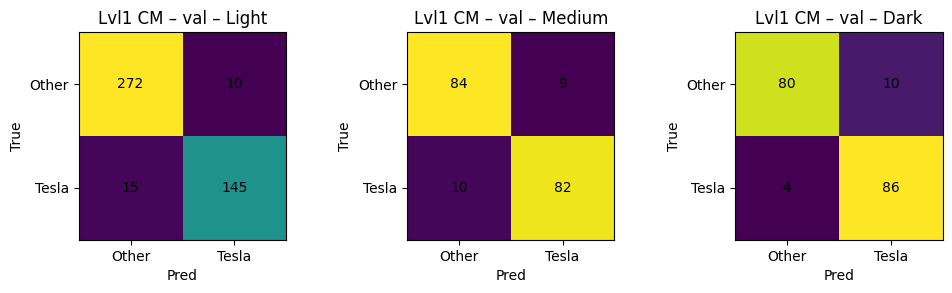

In [6]:

out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5, batch_size=BATCH_SIZE)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))
for ax, light in zip(axes, ("Light", "Medium", "Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)
fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160, bbox_inches="tight")
plt.show()


## Nivå 2-resultater

,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,Total,342,0.760234,0.712950,0.735933,0.374269
1,Light,160,0.725000,0.685016,0.708896,0.362500
2,Medium,92,0.793478,0.710544,0.737233,0.380435
3,Dark,90,0.788889,0.701020,0.705496,0.388889


,class_id,class,support,precision,recall,f1
0,0,3 2017–2023,51,0.681818,0.588235,0.631579
3,3,S 2016–nå,20,0.750000,0.600000,0.666667
4,4,X,41,0.833333,0.609756,0.704225
1,1,3 2024–nå,37,0.764706,0.702703,0.732394
2,2,S 2012–2015,16,0.705882,0.750000,0.727273
6,6,Y 2025-nå,49,0.933333,0.857143,0.893617
5,5,Y 2020–2024,128,0.724359,0.882812,0.795775


,true,pred,rate,support_true
4,X,Y 2020–2024,0.341463,41
0,3 2017–2023,Y 2020–2024,0.254902,51
3,S 2016–nå,Y 2020–2024,0.250000,20
1,3 2024–nå,Y 2020–2024,0.135135,37
2,S 2012–2015,Y 2020–2024,0.125000,16


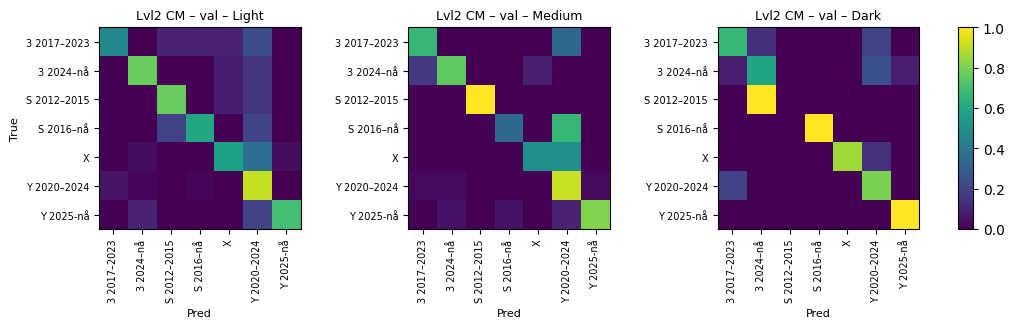

In [8]:

out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_by_light, df_lvl2_per_class, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df, batch_size=BATCH_SIZE)
df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")

display(df_lvl2_by_light)
display(df_lvl2_per_class.head(10))
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))
im = None
for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue
    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)
    ax.set_xticks(range(num_lvl2)); ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2)); ax.set_yticklabels(lvl2_classes, fontsize=7)
    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)
if im is not None:
    cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
    fig.colorbar(im, cax=cax)
fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160, bbox_inches="tight")
plt.show()
